# RQ1 — actor-definition sensitivity (A2 threshold sweep)

**Does the decentralisation picture depend on how we define an "actor"?** The
baseline **A1** treats every distinct pool label as its own actor. **A2** collapses
the long tail of tiny pools into a single "long-tail" actor -- a common,
rarely-scrutinised modelling choice. We sweep the threshold (**0.1 / 0.5 / 1 / 2%**
of all-history share) and compare the metric trajectories. The spread across these
actor definitions is the direct answer to RQ1.

Choices: threshold applied to each pool's **global** (all-history) share, so the set
of "surviving" pools is fixed across time. Attribution held at the baseline **H1/U2**
(tag attribution, unknown excluded). Metrics are computed with the same definitions
as the rest of the thesis.

*Note on direction:* collapsing small pools **merges** share into one entity, so it
tends to raise concentration metrics (HHI, CR) and lower diversity metrics (entropy)
-- watch whether the effect is large or negligible, and which metrics it touches.

In [4]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

attr = pd.read_parquet("../data/derived/attributed_tags.parquet")
print(f"loaded {len(attr):,} blocks; columns: {list(attr.columns)}")

POOL = "pool"
TCOL = "timestamp"
UNKNOWN = {"unknown", "Unknown", "UNKNOWN", None}
print(f"pool column: '{POOL}'  |  timestamp column: '{TCOL}'")

print(f"\npool column detected: '{POOL}'  |  timestamp column: '{TCOL}'")
known_mask = ~attr[POOL].isin(UNKNOWN) & attr[POOL].notna()
print(f"known blocks: {known_mask.sum():,} ({100*known_mask.mean():.1f}%) | "
      f"distinct known pools: {attr.loc[known_mask, POOL].nunique()}")

loaded 954,375 blocks; columns: ['height', 'timestamp', 'pool']
pool column: 'pool'  |  timestamp column: 'timestamp'

pool column detected: 'pool'  |  timestamp column: 'timestamp'
known blocks: 668,409 (70.0%) | distinct known pools: 108


## Metrics (identical definitions to `src/stage3_metrics`)

Self-contained so this notebook needs no imports; higher HHI/Gini/CR = more
concentrated, higher Nakamoto/entropy = more decentralised.

In [5]:
def _shares(counts):
    c = np.asarray(counts, float); s = c.sum()
    return c / s if s > 0 else c

def nakamoto(counts):
    p = np.sort(_shares(counts))[::-1]
    return int(np.searchsorted(np.cumsum(p), 0.5) + 1) if len(p) else 0

def hhi(counts):
    p = _shares(counts); return float(np.sum(p ** 2))

def gini(counts):
    p = np.sort(_shares(counts)); n = len(p)
    if n == 0 or p.sum() == 0: return 0.0
    idx = np.arange(1, n + 1)
    return float((2 * np.sum(idx * p)) / (n * p.sum()) - (n + 1) / n)

def shannon(counts):
    p = _shares(counts); p = p[p > 0]
    return float(-np.sum(p * np.log2(p))) if len(p) else 0.0

def cr(counts, k):
    p = np.sort(_shares(counts))[::-1]; return float(p[:k].sum())

def all_metrics(counts):
    return {"nakamoto": nakamoto(counts), "hhi": hhi(counts), "gini": gini(counts),
            "shannon": shannon(counts), "cr3": cr(counts, 3), "cr5": cr(counts, 5)}

METRICS = ["nakamoto", "hhi", "gini", "shannon", "cr3", "cr5"]

def monthly_series(df, poolcol):
    """Per-month metrics for a labelling (excludes unknown = U2)."""
    d = df[[poolcol, TCOL]].copy()
    d = d[~d[poolcol].isin(UNKNOWN) & d[poolcol].notna()]
    d["month"] = pd.to_datetime(d[TCOL]).dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
    out = {}
    for month, g in d.groupby("month"):
        out[month] = all_metrics(g[poolcol].value_counts().values)
    return pd.DataFrame(out).T.sort_index()

## Global shares and who survives each threshold

In [6]:
gshare = attr.loc[known_mask, POOL].value_counts(normalize=True)
THRESHOLDS = [0.001, 0.005, 0.01, 0.02]

print(f"{'threshold':>10} {'surviving pools':>16} {'long-tail global share':>24}")
print(f"{'A1 (none)':>10} {len(gshare):>16} {'0.0%':>24}")
survivors_by_T = {}
for T in THRESHOLDS:
    surv = set(gshare[gshare >= T].index)
    survivors_by_T[T] = surv
    lt = gshare[gshare < T].sum()
    print(f"{T*100:>9.1f}% {len(surv):>16} {lt*100:>23.1f}%")

 threshold  surviving pools   long-tail global share
 A1 (none)              108                     0.0%
      0.1%               41                     1.4%
      0.5%               26                     5.1%
      1.0%               16                    13.2%
      2.0%               12                    19.3%


## Metric trajectories under each actor definition

In [7]:
series = {"A1": monthly_series(attr, POOL)}
for T in THRESHOLDS:
    surv = survivors_by_T[T]
    actor = attr[POOL].where(attr[POOL].isin(surv) | attr[POOL].isin(UNKNOWN) | attr[POOL].isna(),
                             "long-tail")
    series[f"{T*100:g}%"] = monthly_series(attr.assign(_actor=actor), "_actor")
print("computed monthly series for:", ", ".join(series.keys()))

computed monthly series for: A1, 0.1%, 0.5%, 1%, 2%


## The actor-definition band, per metric

Each panel overlays A1 (black) and the four A2 thresholds. A tight bundle means the
metric is **insensitive** to actor definition; a wide spread means it depends on how
you draw the actor boundary.

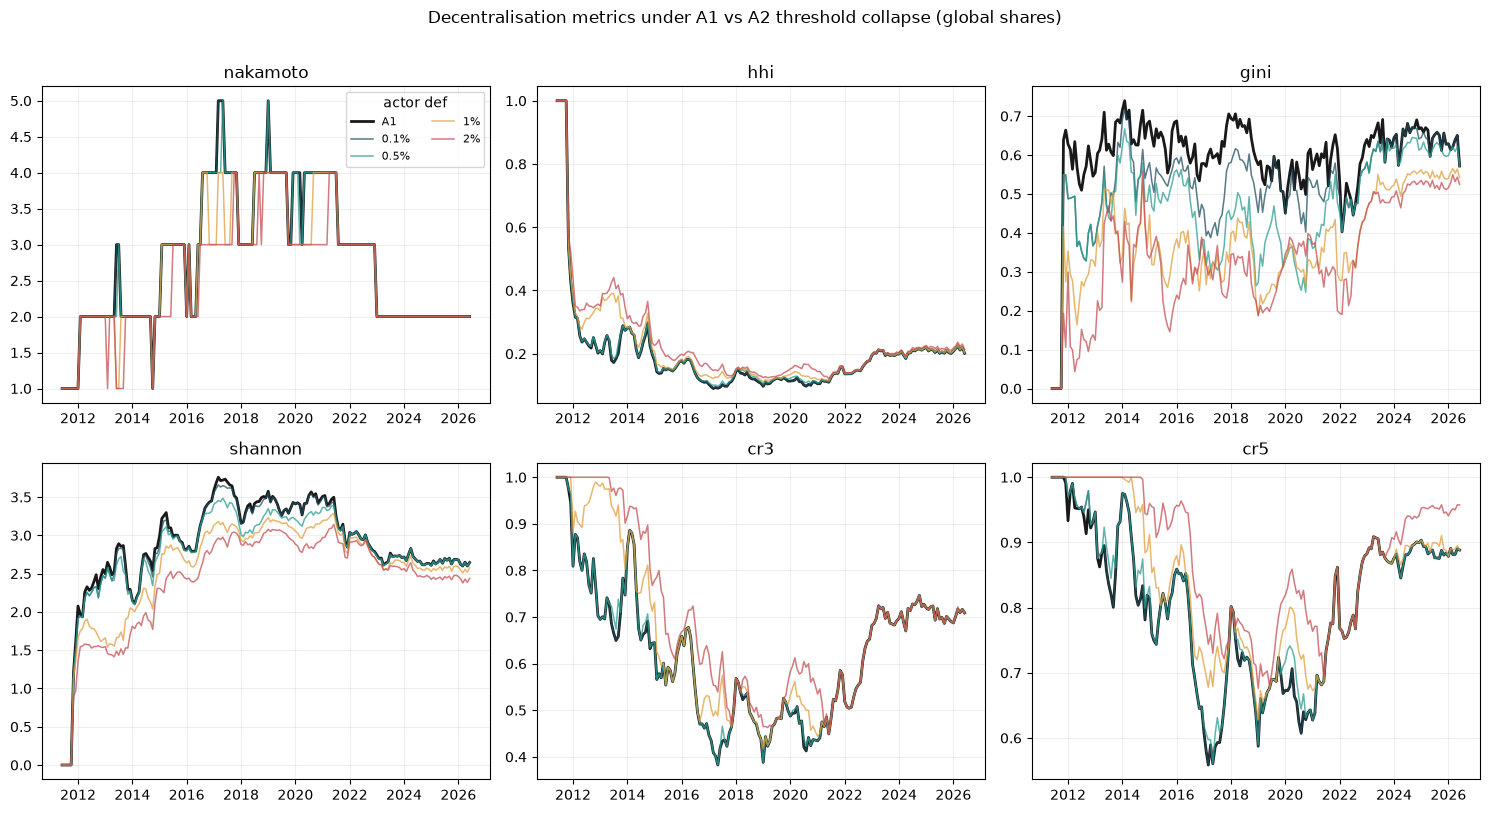

In [8]:
defs = list(series.keys())
colors = {"A1": "black", "0.1%": "#1f4e5f", "0.5%": "#2a9d8f", "1%": "#e09f3e", "2%": "#c44e52"}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, m in zip(axes.ravel(), METRICS):
    for d in defs:
        s = series[d][m]
        ax.plot(s.index, s.values, color=colors.get(d, "gray"),
                lw=2 if d == "A1" else 1.1, alpha=0.9 if d == "A1" else 0.75, label=d)
    ax.set_title(m); ax.grid(alpha=0.2)
axes[0, 0].legend(title="actor def", fontsize=8, ncol=2)
fig.suptitle("Decentralisation metrics under A1 vs A2 threshold collapse (global shares)", y=1.01)
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/actor_threshold_sensitivity.png", dpi=120, bbox_inches="tight")
plt.show()

## Quantify the band (high-coverage era)

For the reliable era (2018+), the mean spread of each metric across the five actor
definitions -- the RQ1 sensitivity number, comparable to your RQ2 heuristic bands.

In [9]:
cutoff = pd.Timestamp("2018-01-01")
common = None
for d in defs:
    idx = series[d].index[series[d].index >= cutoff]
    common = idx if common is None else common.intersection(idx)

print(f"actor-definition band, mean over {len(common)} months (2018+):")
print(f"{'metric':10} {'A1 mean':>9} {'band (max-min)':>15} {'band / A1':>10}")
for m in METRICS:
    stack = np.vstack([series[d].loc[common, m].values for d in defs])
    band = (stack.max(axis=0) - stack.min(axis=0)).mean()
    a1mean = series["A1"].loc[common, m].mean()
    rel = band / a1mean if a1mean else float("nan")
    print(f"{m:10} {a1mean:9.3f} {band:15.3f} {rel:9.1%}")

actor-definition band, mean over 102 months (2018+):
metric       A1 mean  band (max-min)  band / A1
nakamoto       2.931           0.186      6.4%
hhi            0.159           0.015      9.2%
gini           0.603           0.222     36.8%
shannon        3.035           0.284      9.4%
cr3            0.584           0.023      3.9%
cr5            0.785           0.053      6.8%
